In [1]:
#Siddharth Singh Supervised Mini Project
#Tasks:
#1. Import and Load the Data
#•	Import required libraries (pandas, numpy, matplotlib, seaborn, sklearn, etc.)
#•	Load the dataset and explore the structure using .head(), .info() and .describe()
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
print("Libraries Imported Successfully")


Libraries Imported Successfully


In [3]:
df = pd.read_excel("Medical_Insurance_cost_prediction.xlsm")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 1338
Number of Columns : 7


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [13]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [15]:
missing_values = df.isnull().sum()

missing_values

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [17]:

duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows :", duplicate_count)

Number of Duplicate Rows : 1


In [19]:
print("Categorical Columns :")
print(df.select_dtypes(include='object').columns.tolist())

print("\nNumerical Columns :")
print(df.select_dtypes(exclude='object').columns.tolist())

Categorical Columns :
['sex', 'smoker', 'region']

Numerical Columns :
['age', 'bmi', 'children', 'charges']


In [21]:
#2. Exploratory Data Analysis (EDA)
#•	Visualize the distribution of each feature
#•	Understand correlations (especially with the target variable)
#•	Check for variables distributions.
#•	Summarize insights from EDA

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include='object').columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)


Numerical Columns:
['age', 'bmi', 'children', 'charges']

Categorical Columns:
['sex', 'smoker', 'region']


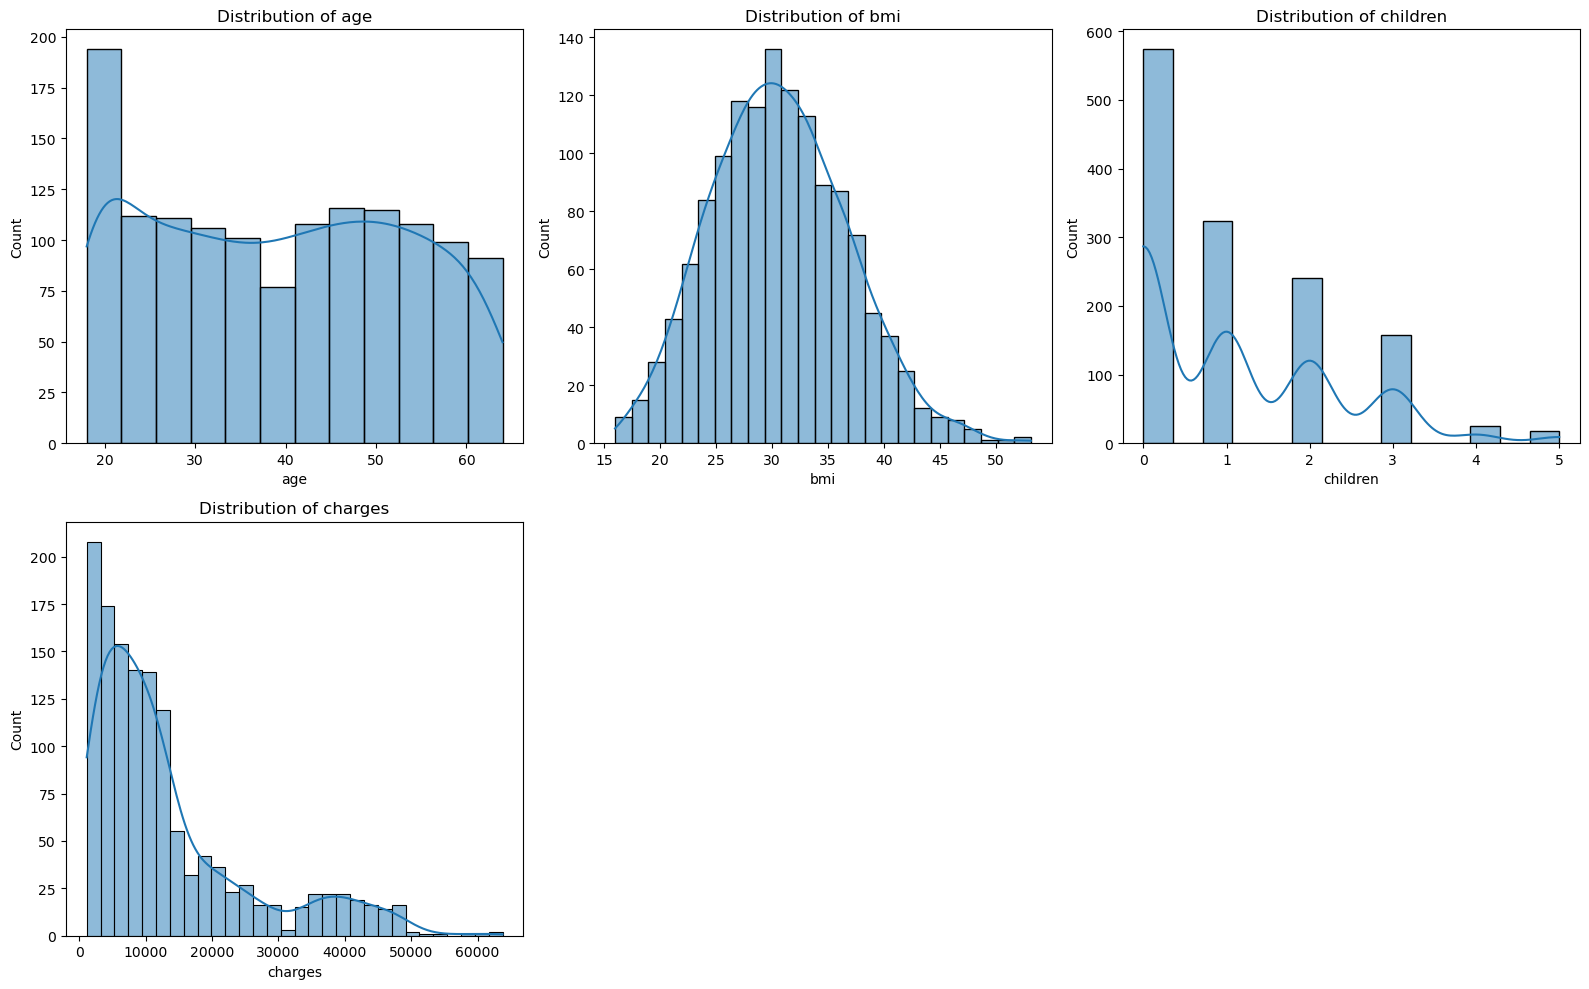

In [23]:

plt.figure(figsize=(16, 10))

for i, column in enumerate(numerical_columns):
    
    plt.subplot(2, 3, i+1)
    
    sns.histplot(
        data=df,
        x=column,
        kde=True
    )
    
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

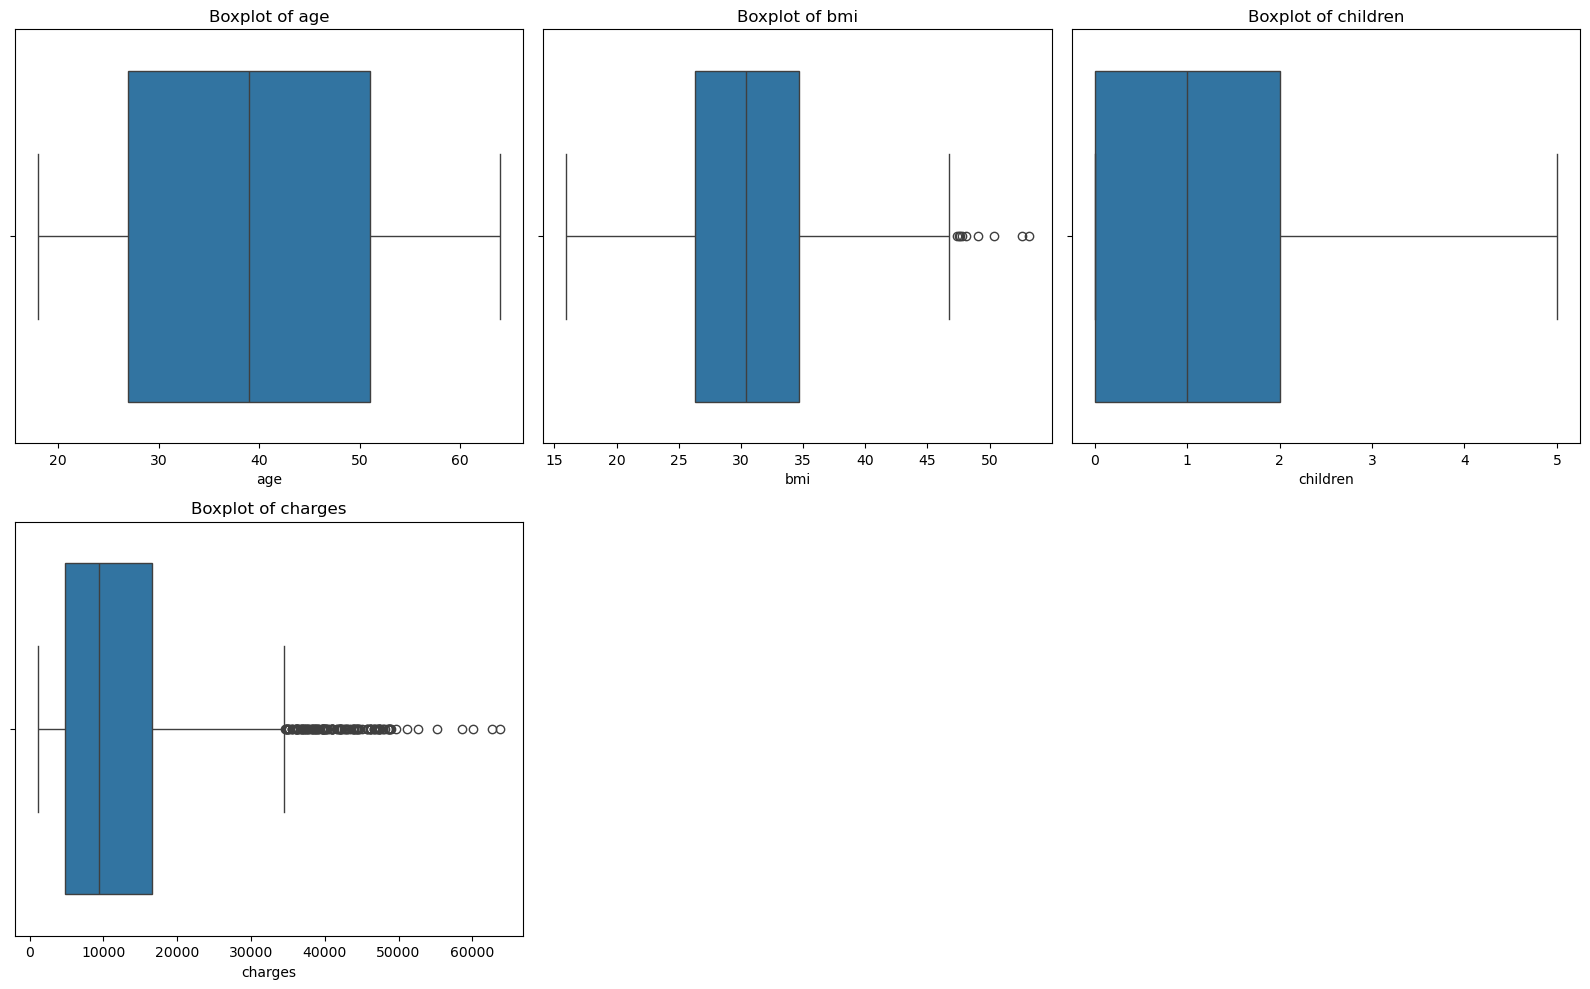

In [25]:
plt.figure(figsize=(16, 10))

for i, column in enumerate(numerical_columns):
    
    plt.subplot(2, 3, i+1)
    
    sns.boxplot(
        x=df[column]
    )
    
    plt.title(f'Boxplot of {column}')

plt.tight_layout()
plt.show()

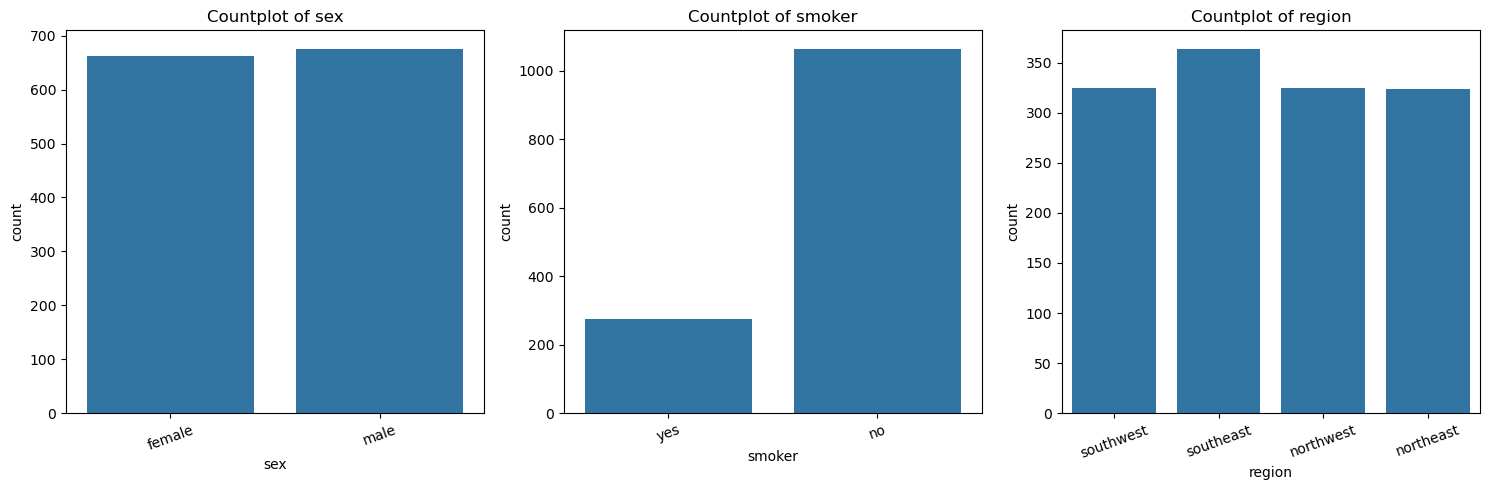

In [27]:
plt.figure(figsize=(15, 5))

for i, column in enumerate(categorical_columns):
    
    plt.subplot(1, 3, i+1)
    
    sns.countplot(
        data=df,
        x=column
    )
    
    plt.title(f'Countplot of {column}')
    
    plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

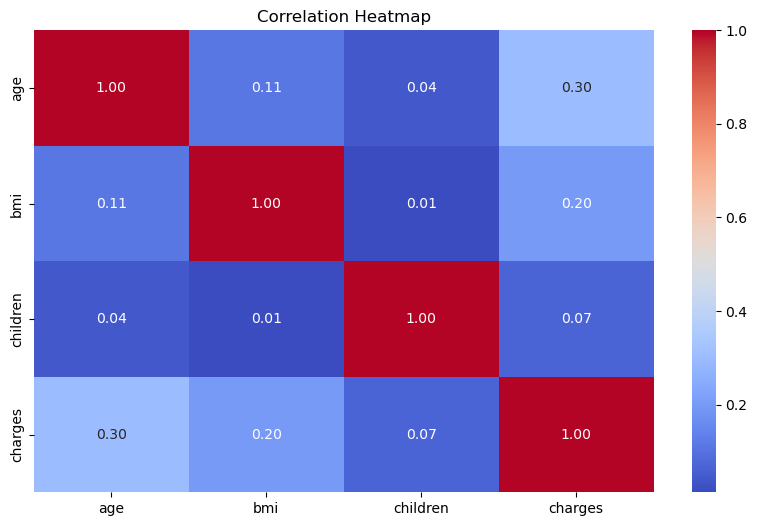

In [29]:

plt.figure(figsize=(10, 6))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

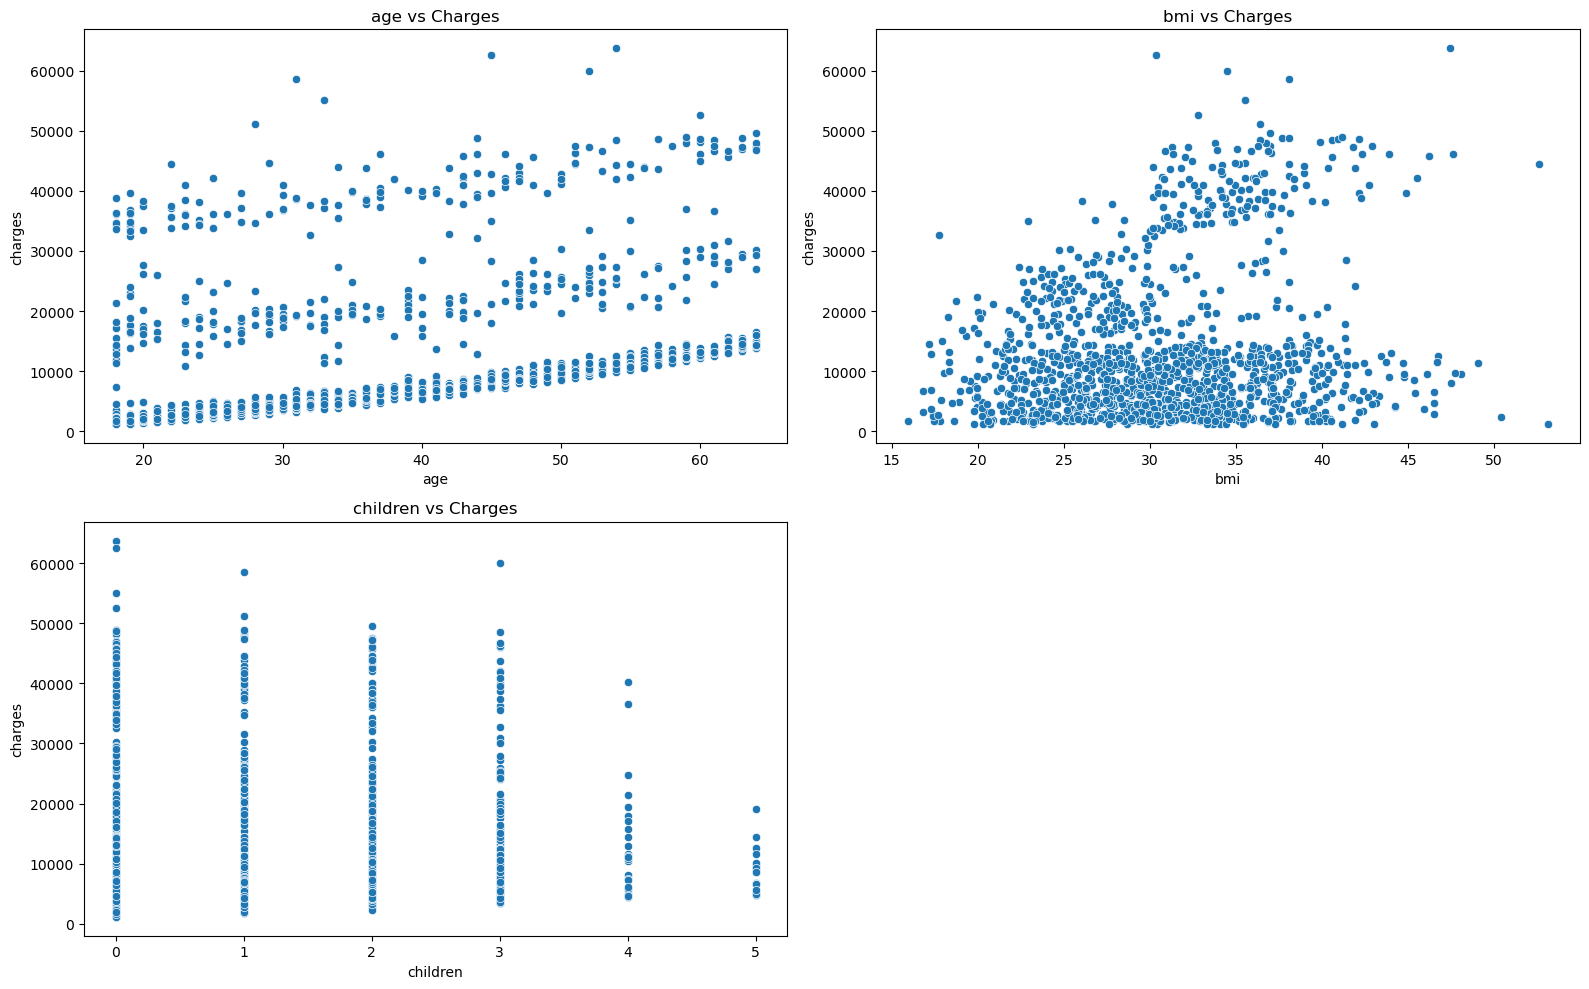

In [31]:

plt.figure(figsize=(16, 10))

features = ['age', 'bmi', 'children']

for i, column in enumerate(features):
    
    plt.subplot(2, 2, i+1)
    
    sns.scatterplot(
        data=df,
        x=column,
        y='charges'
    )
    
    plt.title(f'{column} vs Charges')

plt.tight_layout()
plt.show()

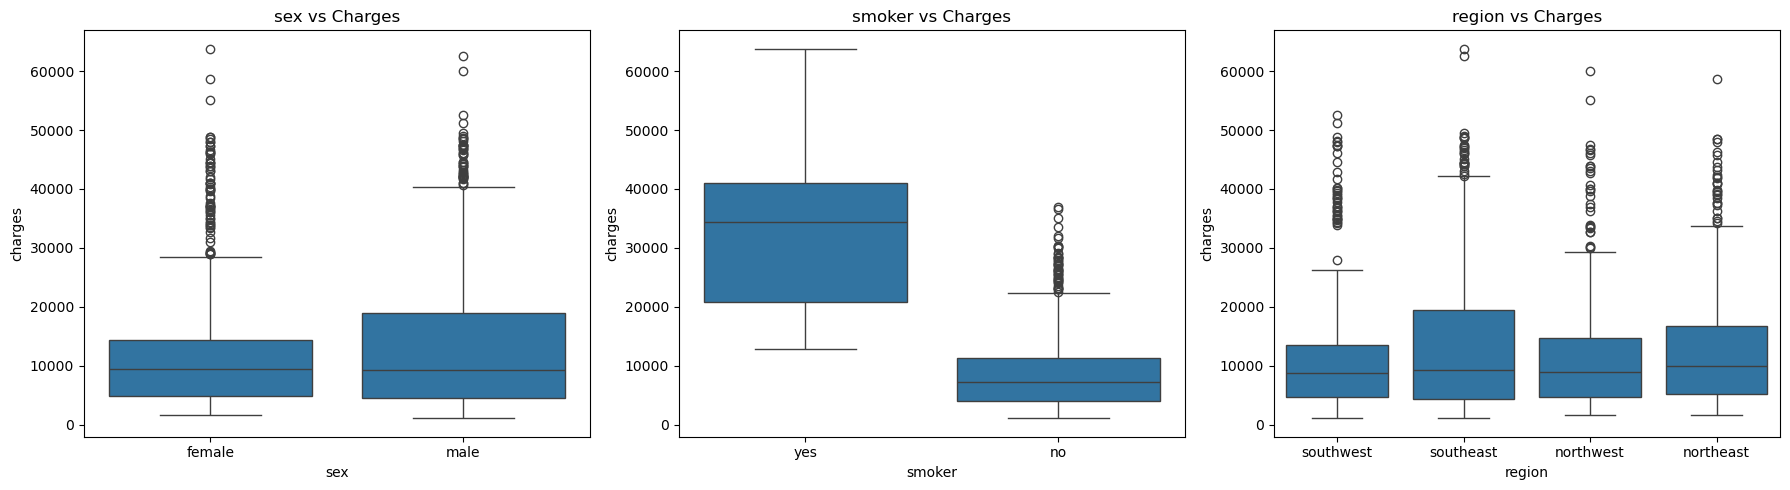

In [33]:

plt.figure(figsize=(18, 5))

for i, column in enumerate(categorical_columns):
    
    plt.subplot(1, 3, i+1)
    
    sns.boxplot(
        data=df,
        x=column,
        y='charges'
    )
    
    plt.title(f'{column} vs Charges')

plt.tight_layout()
plt.show()

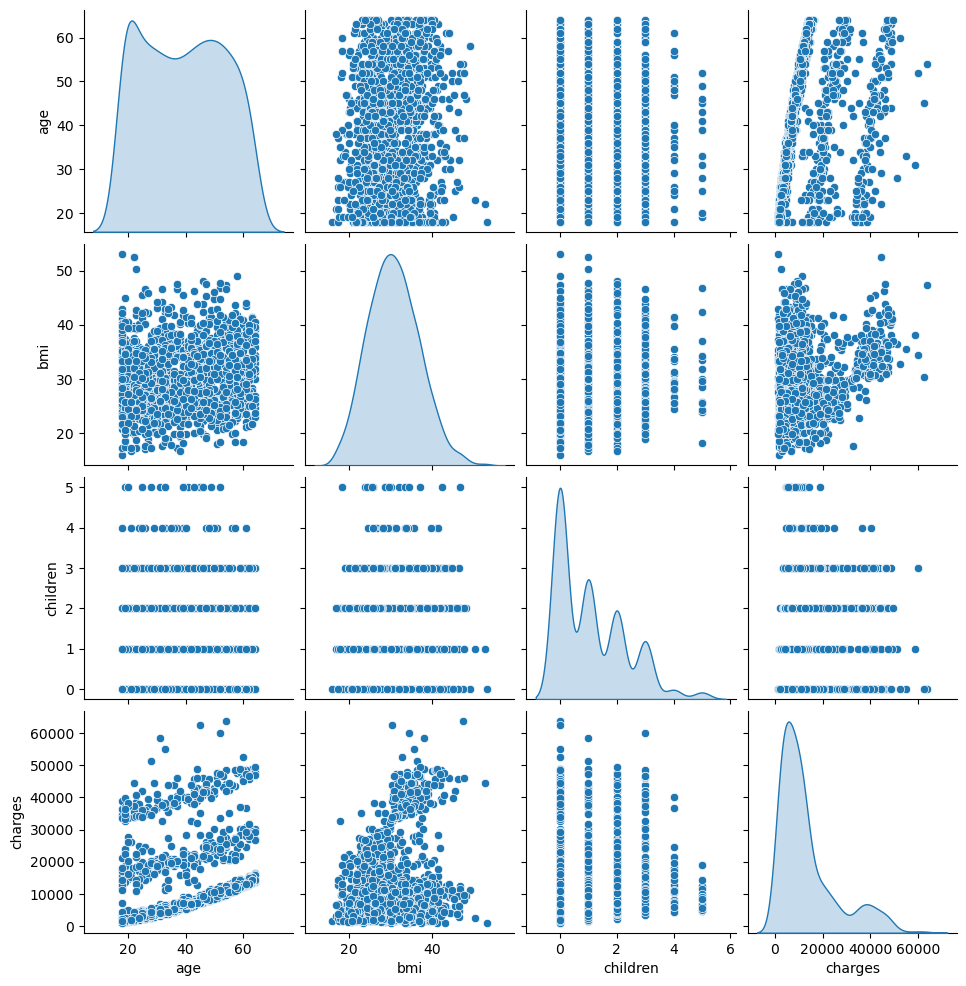

In [35]:

sns.pairplot(
    df,
    diag_kind='kde'
)

plt.show()

In [37]:

skewness = df[numerical_columns].skew().sort_values(ascending=False)

print(skewness)

charges     1.515880
children    0.938380
bmi         0.284047
age         0.055673
dtype: float64


In [39]:
#3. Missing Values & Outlier Treatment
#•	Check for missing values and treat them if any
#•	Check if there are anu outliers.

missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': missing_percentage
})

missing_df


,Missing Count,Missing Percentage
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0


In [41]:

for column in numerical_columns:
    
    if df[column].isnull().sum() > 0:
        
        median_value = df[column].median()
        
        df[column].fillna(
            median_value,
            inplace=True
        )

for column in categorical_columns:
    
    if df[column].isnull().sum() > 0:
        
        mode_value = df[column].mode()[0]
        
        df[column].fillna(
            mode_value,
            inplace=True
        )

print("Missing Value Treatment Completed")

Missing Value Treatment Completed


In [43]:

print("Shape Before Removing Duplicates :", df.shape)

df = df.drop_duplicates()

print("Shape After Removing Duplicates :", df.shape)

Shape Before Removing Duplicates : (1338, 7)
Shape After Removing Duplicates : (1337, 7)


In [45]:

outlier_summary = {}

for column in numerical_columns:
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    outlier_summary[column] = len(outliers)

outlier_summary

{'age': 0, 'bmi': 9, 'children': 0, 'charges': 139}

In [47]:

skew_before = df[numerical_columns].skew()

skew_before

age         0.054781
bmi         0.283914
children    0.937421
charges     1.515391
dtype: float64

In [49]:
df_transformed = df.copy()
df_transformed['charges'] = np.log1p(df_transformed['charges'])
print("Log Transformation Applied on Charges")

Log Transformation Applied on Charges


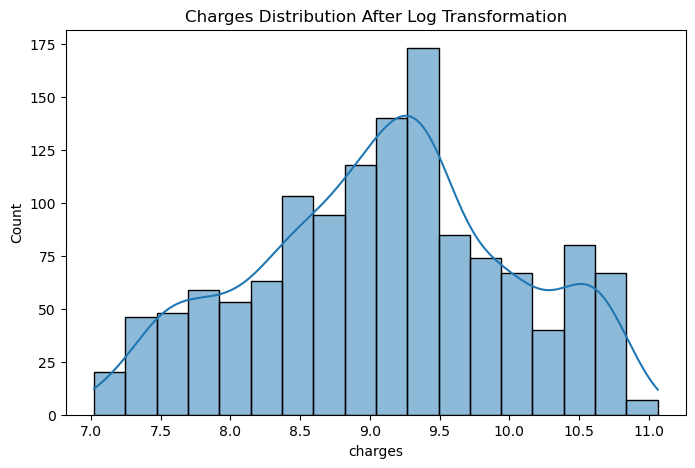

In [51]:

plt.figure(figsize=(8, 5))

sns.histplot(
    df_transformed['charges'],
    kde=True
)

plt.title("Charges Distribution After Log Transformation")
plt.show()

In [53]:

skew_after = df_transformed[numerical_columns].skew()

skew_after

age         0.054781
bmi         0.283914
children    0.937421
charges    -0.089558
dtype: float64

In [55]:

df = df_transformed.copy()

print("Updated Main DataFrame with Transformed Features")

Updated Main DataFrame with Transformed Features


In [57]:
#4. Feature Engineering & Preprocessing
#•	Encode categorical variables (sex, smoker, region)
#•	Feature scaling for numerical values (StandardScaler / MinMaxScaler)
#•	Check for skewness and treat it if required.

for column in categorical_columns:
    
    print(f"\nUnique values in {column}:")
    print(df[column].unique())



Unique values in sex:
['female' 'male']

Unique values in smoker:
['yes' 'no']

Unique values in region:
['southwest' 'southeast' 'northwest' 'northeast']


In [59]:
df_encoded = df.copy()
df_encoded['sex'] = df_encoded['sex'].map({
    'male': 1,
    'female': 0
})
df_encoded['smoker'] = df_encoded['smoker'].map({
    'yes': 1,
    'no': 0
})
print("Binary Encoding Completed")

Binary Encoding Completed


In [61]:
df_encoded = pd.get_dummies(
    df_encoded,
    columns=['region'],
    drop_first=True
)

print("One Hot Encoding Completed")

One Hot Encoding Completed


In [63]:
df_encoded.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,9.734236,False,False,True
1,18,1,33.770,1,0,7.453882,False,True,False
2,28,1,33.000,3,0,8.400763,False,True,False
3,33,1,22.705,0,0,9.998137,True,False,False
4,32,1,28.880,0,0,8.260455,True,False,False


In [65]:
df_encoded['bmi_risk'] = np.where(
    df_encoded['bmi'] >= 30,
    1,
    0
)
df_encoded['age_bmi_interaction'] = (
    df_encoded['age'] * df_encoded['bmi']
)
print("Feature Engineering Completed")

Feature Engineering Completed


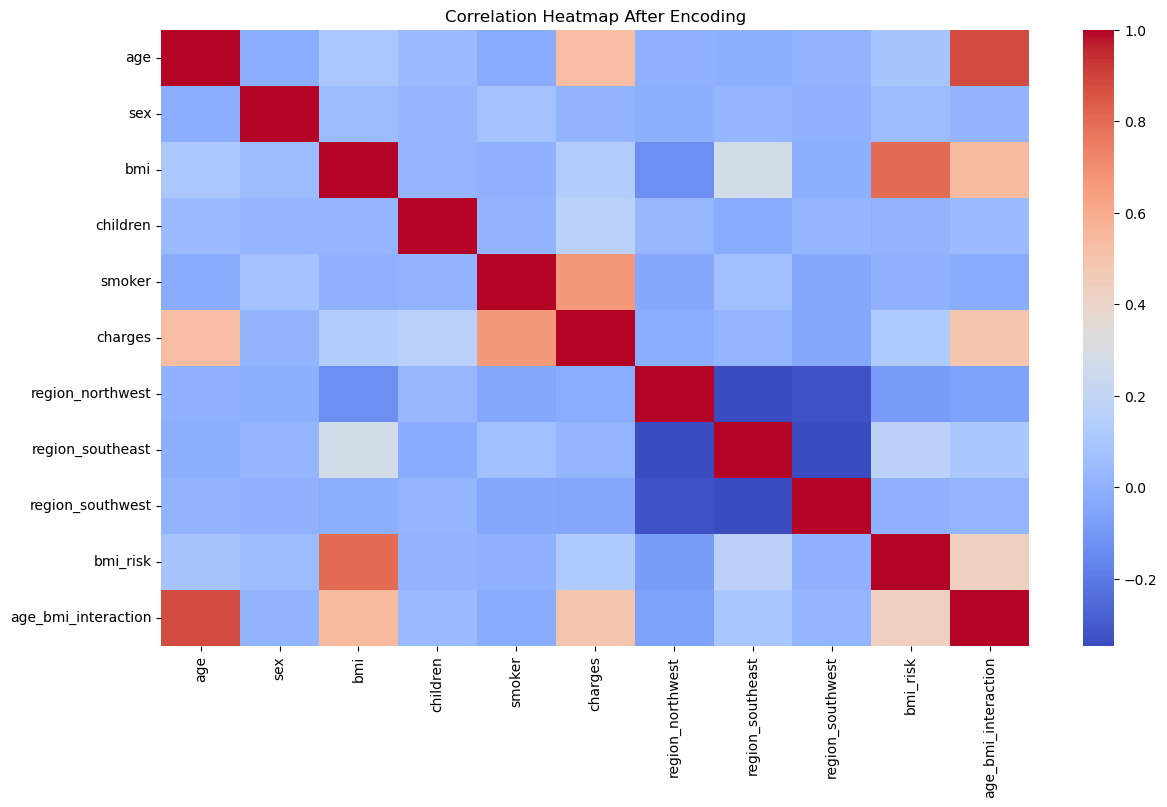

In [67]:
plt.figure(figsize=(14, 8))

correlation_matrix = df_encoded.corr()

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap After Encoding")
plt.show()

In [69]:

X = df_encoded.drop('charges', axis=1)

y = df_encoded['charges']

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (1337, 10)
Target Shape : (1337,)


In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train Shape :", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape : (1069, 10)
X_test Shape : (268, 10)
y_train Shape : (1069,)
y_test Shape : (268,)


In [73]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature Scaling Completed")

Feature Scaling Completed


In [75]:

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

X_train_scaled.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,bmi_risk,age_bmi_interaction
0,-1.157680,0.971409,-0.996928,-0.907908,-0.500292,-0.572669,-0.605812,-0.57411,-1.035232,-1.238320
1,-1.300619,0.971409,-0.792762,0.766904,-0.500292,-0.572669,-0.605812,-0.57411,-1.035232,-1.282726
2,0.914926,-1.029432,1.154664,0.766904,-0.500292,1.746208,-0.605812,-0.57411,0.965967,1.430787
3,1.701087,0.971409,1.806837,-0.907908,-0.500292,-0.572669,1.650678,-0.57411,0.965967,2.702873
4,0.557580,-1.029432,-0.651417,0.766904,-0.500292,-0.572669,-0.605812,-0.57411,-1.035232,0.082162


In [77]:
#5. Model Building: Try Multiple Regressors
#Use all the regression-based models to train and test the data:
#•	Linear Regression
#•	Decision Tree Regressor
#•	Random Forest Regressor
#•	SVR
#•	KNN
#•	Ensemble Learning methods
#6. Model Evaluation & Overfitting Check
#•	Use metrics:
#o	Mean Absolute Error (MAE)
#o	Mean Squared Error (MSE)
#o	Root Mean Squared Error (RMSE)
#o	R² Score
#o	Adjusted R² Score
#•	Compare performance on both datasets (Training and testing) to detect overfitting

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
print("Regression Models Imported Successfully")


Regression Models Imported Successfully


In [79]:

def adjusted_r2_score(r2, n, p):
    
    adjusted_r2 = 1 - (
        (1 - r2) * (n - 1)
    ) / (n - p - 1)
    
    return adjusted_r2

In [81]:
def evaluate_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    model_name
):

    
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
  
    
    train_mae = mean_absolute_error(
        y_train,
        y_train_pred
    )
    
    train_mse = mean_squared_error(
        y_train,
        y_train_pred
    )
    
    train_rmse = np.sqrt(train_mse)
    
    train_r2 = r2_score(
        y_train,
        y_train_pred
    )
    
    train_adj_r2 = adjusted_r2_score(
        train_r2,
        X_train.shape[0],
        X_train.shape[1]
    )
    
    
    test_mae = mean_absolute_error(
        y_test,
        y_test_pred
    )
    
    test_mse = mean_squared_error(
        y_test,
        y_test_pred
    )
    
    test_rmse = np.sqrt(test_mse)
    
    test_r2 = r2_score(
        y_test,
        y_test_pred
    )
    
    test_adj_r2 = adjusted_r2_score(
        test_r2,
        X_test.shape[0],
        X_test.shape[1]
    )
    
    
    overfitting = (
        "Yes"
        if (train_r2 - test_r2) > 0.10
        else "No"
    )
    

    
    results = {
        'Model': model_name,
        
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        
        'Train R2': train_r2,
        'Test R2': test_r2,
        
        'Train Adjusted R2': train_adj_r2,
        'Test Adjusted R2': test_adj_r2,
        
        'Overfitting': overfitting
    }
    
    return results

In [83]:
models = {

    'Linear Regression': LinearRegression(),

    'Decision Tree': DecisionTreeRegressor(
        random_state=42
    ),

    'Random Forest': RandomForestRegressor(
        random_state=42
    ),

    'KNN Regressor': KNeighborsRegressor(),

    'SVR': SVR(),

    'Gradient Boosting': GradientBoostingRegressor(
        random_state=42
    ),

    'Extra Trees': ExtraTreesRegressor(
        random_state=42
    ),

    'AdaBoost': AdaBoostRegressor(
        random_state=42
    )
}

In [85]:

model_results = []

for model_name, model in models.items():
    
    result = evaluate_model(
        model,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test,
        model_name
    )
    
    model_results.append(result)

print("All Models Trained Successfully")

All Models Trained Successfully


In [87]:

results_df = pd.DataFrame(model_results)

results_df

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Overfitting
0,Linear Regression,2.839608e-01,0.262316,4.519024e-01,0.399692,0.751413,0.827831,0.749063,0.821132,No
1,Decision Tree,0.000000e+00,0.214671,0.000000e+00,0.478403,1.000000,0.753343,1.000000,0.743746,Yes
2,Random Forest,8.186767e-02,0.203376,1.560638e-01,0.384907,0.970352,0.840333,0.970072,0.834120,Yes
3,KNN Regressor,1.970906e-01,0.235249,3.493503e-01,0.383530,0.851437,0.841473,0.850032,0.835305,No
4,SVR,1.561675e-01,0.154768,3.724699e-01,0.324638,0.831122,0.886420,0.829526,0.882000,No
5,Gradient Boosting,1.592857e-01,0.184704,3.032756e-01,0.333445,0.888040,0.880174,0.886981,0.875511,No
6,Extra Trees,1.214038e-14,0.204694,1.368695e-14,0.415754,1.000000,0.813715,1.000000,0.806467,Yes
7,AdaBoost,3.027725e-01,0.282850,4.335980e-01,0.405749,0.771143,0.822573,0.768980,0.815669,No


In [89]:

results_df = results_df.sort_values(
    by='Test R2',
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Overfitting
0,SVR,1.561675e-01,0.154768,3.724699e-01,0.324638,0.831122,0.886420,0.829526,0.882000,No
1,Gradient Boosting,1.592857e-01,0.184704,3.032756e-01,0.333445,0.888040,0.880174,0.886981,0.875511,No
2,KNN Regressor,1.970906e-01,0.235249,3.493503e-01,0.383530,0.851437,0.841473,0.850032,0.835305,No
3,Random Forest,8.186767e-02,0.203376,1.560638e-01,0.384907,0.970352,0.840333,0.970072,0.834120,Yes
4,Linear Regression,2.839608e-01,0.262316,4.519024e-01,0.399692,0.751413,0.827831,0.749063,0.821132,No
5,AdaBoost,3.027725e-01,0.282850,4.335980e-01,0.405749,0.771143,0.822573,0.768980,0.815669,No
6,Extra Trees,1.214038e-14,0.204694,1.368695e-14,0.415754,1.000000,0.813715,1.000000,0.806467,Yes
7,Decision Tree,0.000000e+00,0.214671,0.000000e+00,0.478403,1.000000,0.753343,1.000000,0.743746,Yes


In [91]:

best_model = results_df.iloc[0]['Model']

print("Best Performing Model :", best_model)

Best Performing Model : SVR


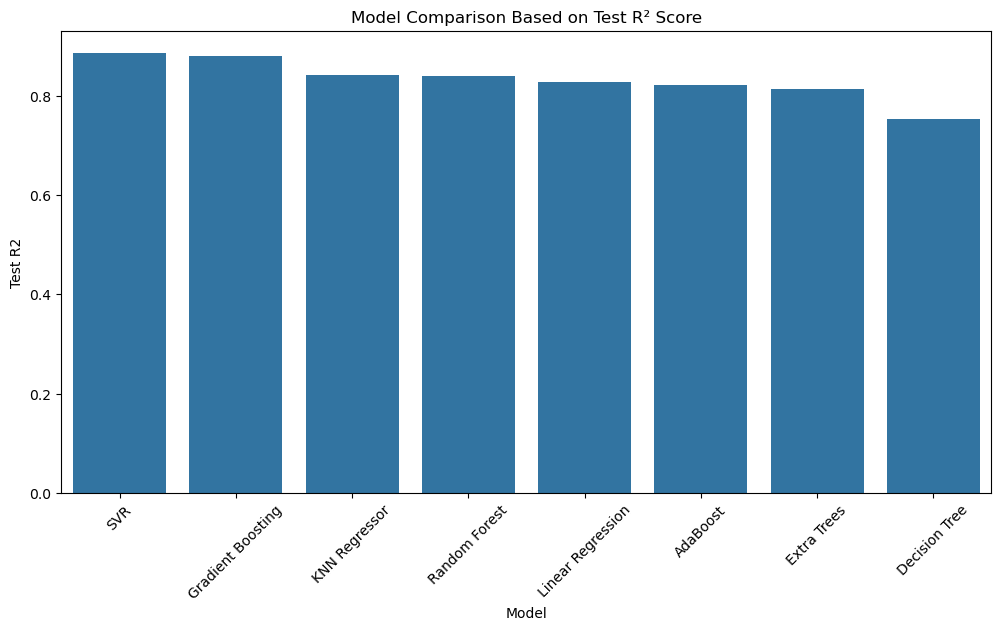

In [93]:

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x='Model',
    y='Test R2'
)

plt.xticks(rotation=45)

plt.title("Model Comparison Based on Test R² Score")

plt.show()

In [95]:

comparison_df = results_df[
    ['Model', 'Train RMSE', 'Test RMSE']
]

comparison_df

,Model,Train RMSE,Test RMSE
0,SVR,3.724699e-01,0.324638
1,Gradient Boosting,3.032756e-01,0.333445
2,KNN Regressor,3.493503e-01,0.383530
3,Random Forest,1.560638e-01,0.384907
4,Linear Regression,4.519024e-01,0.399692
5,AdaBoost,4.335980e-01,0.405749
6,Extra Trees,1.368695e-14,0.415754
7,Decision Tree,0.000000e+00,0.478403


In [97]:

results_df[
    ['Model', 'Train R2', 'Test R2', 'Overfitting']
]

,Model,Train R2,Test R2,Overfitting
0,SVR,0.831122,0.886420,No
1,Gradient Boosting,0.888040,0.880174,No
2,KNN Regressor,0.851437,0.841473,No
3,Random Forest,0.970352,0.840333,Yes
4,Linear Regression,0.751413,0.827831,No
5,AdaBoost,0.771143,0.822573,No
6,Extra Trees,1.000000,0.813715,Yes
7,Decision Tree,1.000000,0.753343,Yes


In [99]:
#7. Hyperparameter Tuning
#•	Use GridSearchCV or RandomizedSearchCV to optimize the best-performing models
#•	Document best parameters and improvement in performance

from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV
)

print("Hyperparameter Tuning Libraries Imported")



Hyperparameter Tuning Libraries Imported


In [101]:
svr_params = {
    
    'C': [0.1, 1, 10, 100],
    
    'gamma': ['scale', 'auto', 0.1, 0.01],
    
    'kernel': ['rbf', 'linear']
}

svr_model = SVR()

svr_random_search = RandomizedSearchCV(
    
    estimator=svr_model,
    
    param_distributions=svr_params,
    
    n_iter=10,
    
    scoring='r2',
    
    cv=5,
    
    verbose=1,
    
    random_state=42,
    
    n_jobs=-1
)

svr_random_search.fit(
    X_train_scaled,
    y_train
)

print("Best Parameters:")
print(svr_random_search.best_params_)

print("\nBest Cross Validation Score:")
print(svr_random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters:
{'kernel': 'rbf', 'gamma': 0.01, 'C': 100}

Best Cross Validation Score:
0.8253965474537083


In [102]:

best_svr = svr_random_search.best_estimator_

best_svr_result = evaluate_model(
    
    best_svr,
    
    X_train_scaled,
    X_test_scaled,
    
    y_train,
    y_test,
    
    "Tuned SVR"
)

pd.DataFrame([best_svr_result])

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Overfitting
0,Tuned SVR,0.163009,0.14643,0.374404,0.310024,0.829364,0.896416,0.827751,0.892385,No


In [105]:
gb_params = {
    
    'n_estimators': [50, 100, 200],
    
    'learning_rate': [0.01, 0.05, 0.1],
    
    'max_depth': [2, 3, 4],
    
    'subsample': [0.8, 1.0]
}

gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_random_search = RandomizedSearchCV(
    
    estimator=gb_model,
    
    param_distributions=gb_params,
    
    n_iter=10,
    
    scoring='r2',
    
    cv=5,
    
    verbose=1,
    
    random_state=42,
    
    n_jobs=-1
)

gb_random_search.fit(
    X_train_scaled,
    y_train
)

print("Best Parameters:")
print(gb_random_search.best_params_)

print("\nBest Cross Validation Score:")
print(gb_random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters:
{'subsample': 0.8, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05}

Best Cross Validation Score:
0.811306474974448


In [107]:

best_gb = gb_random_search.best_estimator_

best_gb_result = evaluate_model(
    
    best_gb,
    
    X_train_scaled,
    X_test_scaled,
    
    y_train,
    y_test,
    
    "Tuned Gradient Boosting"
)

pd.DataFrame([best_gb_result])

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Overfitting
0,Tuned Gradient Boosting,0.161997,0.188686,0.304149,0.338041,0.887394,0.876848,0.886329,0.872056,No


In [109]:
rf_params = {
    
    'n_estimators': [100, 200, 300],
    
    'max_depth': [5, 10, 15, None],
    
    'min_samples_split': [2, 5, 10],
    
    'min_samples_leaf': [1, 2, 4]
}

rf_model = RandomForestRegressor(
    random_state=42
)

rf_random_search = RandomizedSearchCV(
    
    estimator=rf_model,
    
    param_distributions=rf_params,
    
    n_iter=10,
    
    scoring='r2',
    
    cv=5,
    
    verbose=1,
    
    random_state=42,
    
    n_jobs=-1
)

rf_random_search.fit(
    X_train_scaled,
    y_train
)

print("Best Parameters:")
print(rf_random_search.best_params_)

print("\nBest Cross Validation Score:")
print(rf_random_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5}

Best Cross Validation Score:
0.8121208132163857


In [110]:

best_rf = rf_random_search.best_estimator_

best_rf_result = evaluate_model(
    
    best_rf,
    
    X_train_scaled,
    X_test_scaled,
    
    y_train,
    y_test,
    
    "Tuned Random Forest"
)

pd.DataFrame([best_rf_result])

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Overfitting
0,Tuned Random Forest,0.183163,0.182548,0.3516,0.337747,0.849517,0.877062,0.848094,0.872278,No


In [113]:

tuned_results = pd.DataFrame([
    
    best_svr_result,
    
    best_gb_result,
    
    best_rf_result
])

tuned_results = tuned_results.sort_values(
    by='Test R2',
    ascending=False
)

tuned_results.reset_index(
    drop=True,
    inplace=True
)

tuned_results

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Overfitting
0,Tuned SVR,0.163009,0.146430,0.374404,0.310024,0.829364,0.896416,0.827751,0.892385,No
1,Tuned Random Forest,0.183163,0.182548,0.351600,0.337747,0.849517,0.877062,0.848094,0.872278,No
2,Tuned Gradient Boosting,0.161997,0.188686,0.304149,0.338041,0.887394,0.876848,0.886329,0.872056,No


In [115]:

final_best_model = tuned_results.iloc[0]['Model']

print("Final Best Model :", final_best_model)

Final Best Model : Tuned SVR


In [117]:

final_comparison = pd.concat([
    
    results_df,
    tuned_results
    
], ignore_index=True)

final_comparison = final_comparison.sort_values(
    by='Test R2',
    ascending=False
)

final_comparison.reset_index(
    drop=True,
    inplace=True
)

final_comparison

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Overfitting
0,Tuned SVR,1.630088e-01,0.146430,3.744041e-01,0.310024,0.829364,0.896416,0.827751,0.892385,No
1,SVR,1.561675e-01,0.154768,3.724699e-01,0.324638,0.831122,0.886420,0.829526,0.882000,No
2,Gradient Boosting,1.592857e-01,0.184704,3.032756e-01,0.333445,0.888040,0.880174,0.886981,0.875511,No
3,Tuned Random Forest,1.831633e-01,0.182548,3.516002e-01,0.337747,0.849517,0.877062,0.848094,0.872278,No
4,Tuned Gradient Boosting,1.619969e-01,0.188686,3.041491e-01,0.338041,0.887394,0.876848,0.886329,0.872056,No
5,KNN Regressor,1.970906e-01,0.235249,3.493503e-01,0.383530,0.851437,0.841473,0.850032,0.835305,No
6,Random Forest,8.186767e-02,0.203376,1.560638e-01,0.384907,0.970352,0.840333,0.970072,0.834120,Yes
7,Linear Regression,2.839608e-01,0.262316,4.519024e-01,0.399692,0.751413,0.827831,0.749063,0.821132,No
8,AdaBoost,3.027725e-01,0.282850,4.335980e-01,0.405749,0.771143,0.822573,0.768980,0.815669,No
9,Extra Trees,1.214038e-14,0.204694,1.368695e-14,0.415754,1.000000,0.813715,1.000000,0.806467,Yes


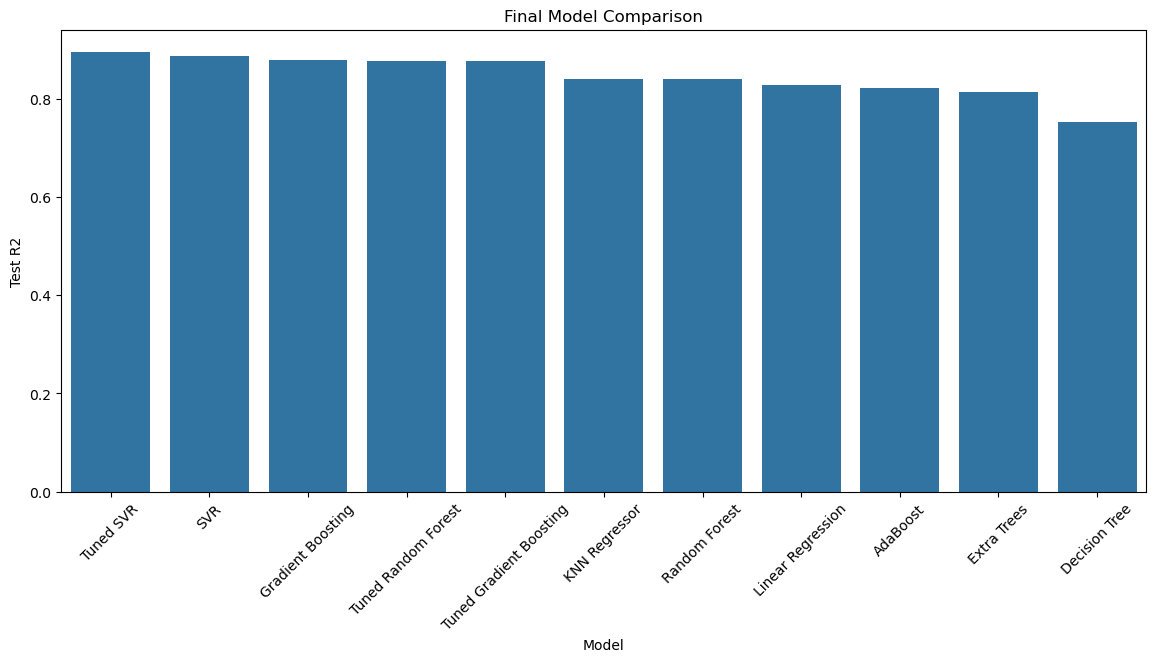

In [119]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=final_comparison,
    x='Model',
    y='Test R2'
)

plt.xticks(rotation=45)

plt.title("Final Model Comparison")

plt.show()

In [121]:

feature_importance = pd.DataFrame({

    'Feature': X.columns,
    
    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
4,smoker,0.500575
0,age,0.397967
3,children,0.042355
2,bmi,0.031740
9,age_bmi_interaction,0.016031
8,bmi_risk,0.005295
5,region_northwest,0.002934
1,sex,0.002070
7,region_southwest,0.000609
6,region_southeast,0.000425


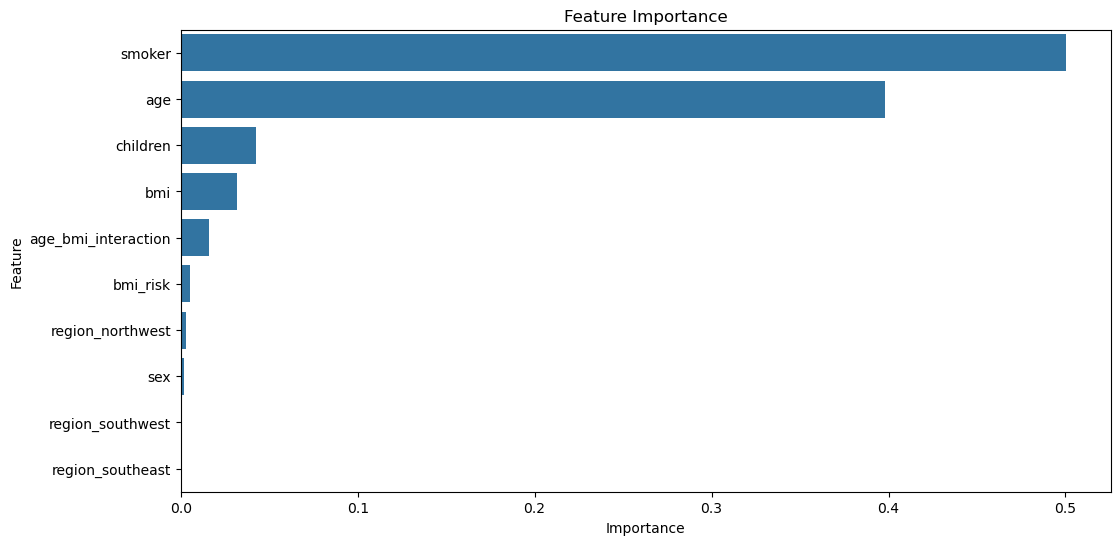

In [123]:

plt.figure(figsize=(12, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

In [125]:

final_model = best_svr

print("Final Selected Model : Tuned SVR")

Final Selected Model : Tuned SVR


In [127]:
def predict_insurance_cost(
    
    age,
    sex,
    bmi,
    children,
    smoker,
    region
):
    
    
    
    sex = 1 if sex.lower() == 'male' else 0
    
    smoker = 1 if smoker.lower() == 'yes' else 0
    
    region_northwest = 0
    region_southeast = 0
    region_southwest = 0
    
    if region.lower() == 'northwest':
        region_northwest = 1
        
    elif region.lower() == 'southeast':
        region_southeast = 1
        
    elif region.lower() == 'southwest':
        region_southwest = 1
   
    
    bmi_risk = 1 if bmi >= 30 else 0
    
    age_bmi_interaction = age * bmi
 
    input_data = pd.DataFrame([[
        
        age,
        sex,
        bmi,
        children,
        smoker,
        
        region_northwest,
        region_southeast,
        region_southwest,
        
        bmi_risk,
        age_bmi_interaction
        
    ]], columns=X.columns)
    
    
    
    input_scaled = scaler.transform(input_data)
    
 
    
    prediction_log = final_model.predict(input_scaled)
    
    # Reverse log transformation
    prediction = np.expm1(prediction_log)
    
    return prediction[0]

In [129]:

predicted_cost = predict_insurance_cost(
    
    age=35,
    sex='male',
    bmi=28.5,
    children=2,
    smoker='no',
    region='southeast'
)

print("Predicted Insurance Cost : $", round(predicted_cost, 2))

Predicted Insurance Cost : $ 5679.98


In [131]:

y_train_pred = final_model.predict(X_train_scaled)

y_test_pred = final_model.predict(X_test_scaled)

In [133]:

train_residuals = y_train - y_train_pred

test_residuals = y_test - y_test_pred

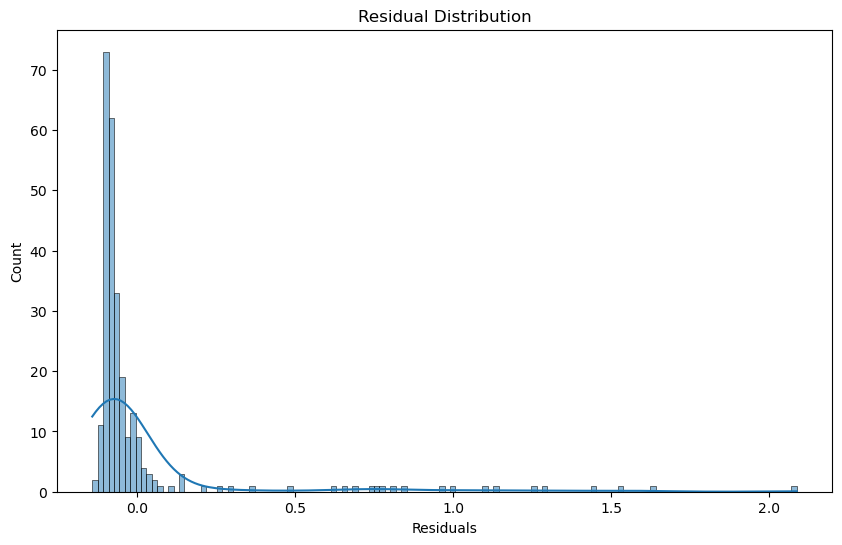

In [135]:

plt.figure(figsize=(10, 6))

sns.histplot(
    test_residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.xlabel("Residuals")

plt.show()

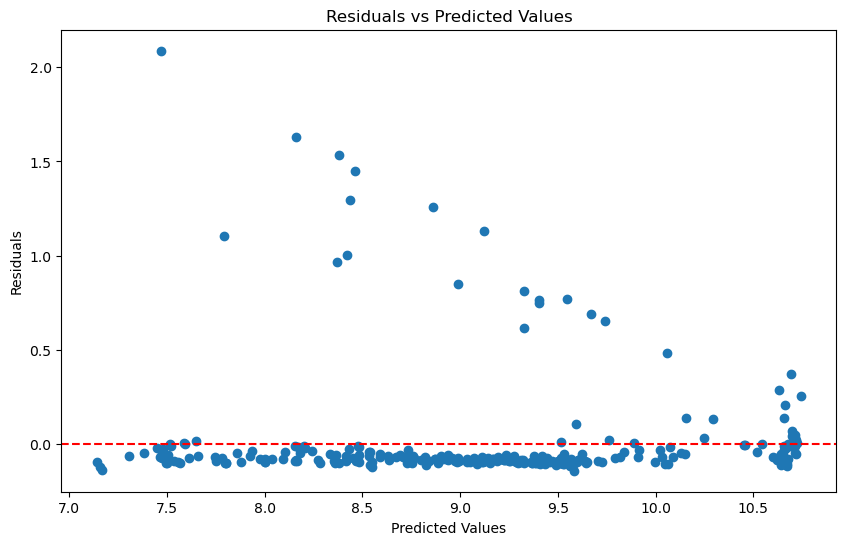

In [137]:

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test_pred,
    test_residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residuals vs Predicted Values")

plt.show()

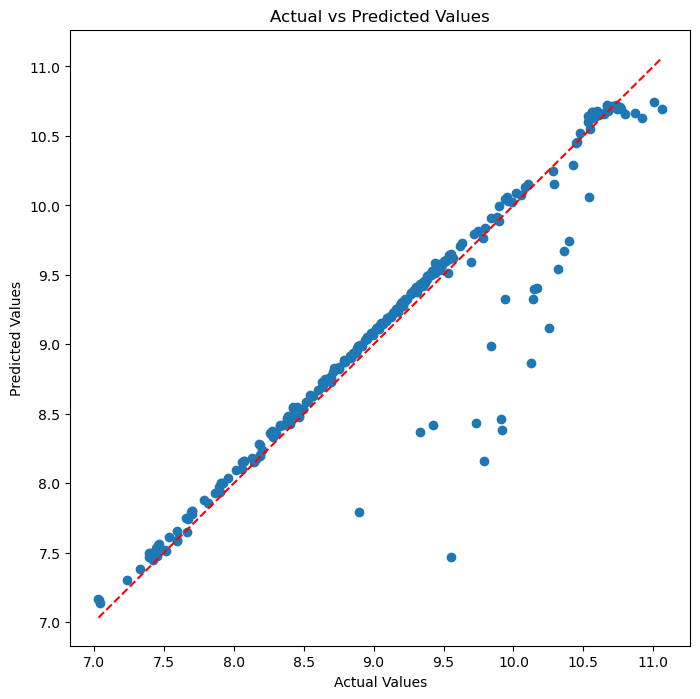

In [139]:

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    y_test_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Values")

plt.show()

In [141]:

from sklearn.model_selection import cross_val_score

In [143]:

cv_scores = cross_val_score(
    
    final_model,
    
    X_train_scaled,
    
    y_train,
    
    cv=5,
    
    scoring='r2'
)

print("Cross Validation Scores:\n")

print(cv_scores)

print("\nAverage CV Score:")

print(cv_scores.mean())

Cross Validation Scores:

[0.76354215 0.87365993 0.8081298  0.8317255  0.84992536]

Average CV Score:
0.8253965474537083


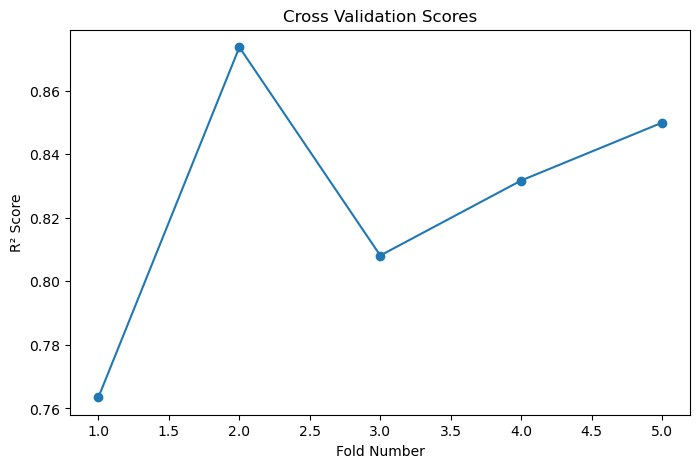

In [145]:

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 6),
    cv_scores,
    marker='o'
)

plt.xlabel("Fold Number")

plt.ylabel("R² Score")

plt.title("Cross Validation Scores")

plt.show()

In [147]:
import pickle

In [149]:

pickle.dump(
    final_model,
    
    open('medical_insurance_model.pkl', 'wb')
)

print("Model Saved Successfully")

Model Saved Successfully


In [151]:

pickle.dump(
    scaler,
    
    open('scaler.pkl', 'wb')
)

print("Scaler Saved Successfully")

Scaler Saved Successfully


In [153]:

loaded_model = pickle.load(
    open('medical_insurance_model.pkl', 'rb')
)

print("Saved Model Loaded Successfully")

Saved Model Loaded Successfully


In [155]:
!pip install xgboost

In [157]:
from xgboost import XGBRegressor

In [159]:
xgb_model = XGBRegressor(
    
    n_estimators=100,
    
    learning_rate=0.1,
    
    max_depth=3,
    
    random_state=42
)

xgb_result = evaluate_model(
    
    xgb_model,
    
    X_train_scaled,
    X_test_scaled,
    
    y_train,
    y_test,
    
    "XGBoost"
)

pd.DataFrame([xgb_result])

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Overfitting
0,XGBoost,0.165372,0.196687,0.313574,0.340988,0.880307,0.874691,0.879176,0.869815,No


In [161]:

ultimate_results = pd.concat([
    
    final_comparison,
    
    pd.DataFrame([xgb_result])
    
], ignore_index=True)

ultimate_results = ultimate_results.sort_values(
    by='Test R2',
    ascending=False
)

ultimate_results.reset_index(
    drop=True,
    inplace=True
)

ultimate_results

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,Train Adjusted R2,Test Adjusted R2,Overfitting
0,Tuned SVR,1.630088e-01,0.146430,3.744041e-01,0.310024,0.829364,0.896416,0.827751,0.892385,No
1,SVR,1.561675e-01,0.154768,3.724699e-01,0.324638,0.831122,0.886420,0.829526,0.882000,No
2,Gradient Boosting,1.592857e-01,0.184704,3.032756e-01,0.333445,0.888040,0.880174,0.886981,0.875511,No
3,Tuned Random Forest,1.831633e-01,0.182548,3.516002e-01,0.337747,0.849517,0.877062,0.848094,0.872278,No
4,Tuned Gradient Boosting,1.619969e-01,0.188686,3.041491e-01,0.338041,0.887394,0.876848,0.886329,0.872056,No
5,XGBoost,1.653716e-01,0.196687,3.135735e-01,0.340988,0.880307,0.874691,0.879176,0.869815,No
6,KNN Regressor,1.970906e-01,0.235249,3.493503e-01,0.383530,0.851437,0.841473,0.850032,0.835305,No
7,Random Forest,8.186767e-02,0.203376,1.560638e-01,0.384907,0.970352,0.840333,0.970072,0.834120,Yes
8,Linear Regression,2.839608e-01,0.262316,4.519024e-01,0.399692,0.751413,0.827831,0.749063,0.821132,No
9,AdaBoost,3.027725e-01,0.282850,4.335980e-01,0.405749,0.771143,0.822573,0.768980,0.815669,No


In [163]:
import os

print(os.listdir())

['.aienv_fea2.024.2_cache', '.aienv_options', '.anaconda', '.ansys', '.cache', '.cfx', '.claude', '.claude.json', '.codex', '.conda', '.condarc', '.continuum', '.copilot', '.cufflinks', '.cursor', '.cxlayout.ini', '.flrecent', '.fluentconf', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.matplotlib', '.ms-ad', '.sbx-denybin', '.spyder-py3', '.ssh', '.streamlit', '.viminfo', '.vscode', '.vscode-shared', '03_Clustering_Marketing.csv', 'anaconda3', 'Anaconda3-2025.12-2-Windows-x86_64.exe', 'anaconda_projects', 'anime.csv', 'ansel', 'ansys.atr', 'ansys.fbc', 'ansys.fbc_old', 'AppData', 'Application Data', 'archive (1).zip', 'archive (3).zip', 'axial_velocity.png', 'AyushAnand_Unsupervised_ML.ipynb', 'AYUSH_WEEK5', 'best_ann_model.keras', 'best_cnn_model.keras', 'Billionaires_Stats.csv', 'Cellphone.csv', 'cleanup-fluent-Siddharth-19020.bat', 'cleanup-fluent-Siddharth-19376.bat', 'cleanup-fluent-Siddharth-20456.bat', 'cleanup-fluent-Siddharth-21040.bat', 'cleanup-flu

In [165]:
import os

print(os.getcwd())

C:\Users\siddh


In [ ]:
#https://medical-insurance-predictor-sid1610.streamlit.app/